# Simulated auditory TRF — what you can only check when you know the answer

A tour of TRFlearn on **synthetic** data: a known temporal response function is convolved
with a speech-like stimulus, projected onto a real 10–20 montage and buried in noise. Then
we try to get it back.

Everything here runs as soon as the package and its `simulation` extra are installed —
no downloads, no external data.

**This notebook deliberately does not repeat the plotting tour or the group workflow.**
Those are shown on real data in
[`examples/02_natural_speech_trf.ipynb`](../../examples/02_natural_speech_trf/). What is
kept here is the set of things that are *only* possible when the ground truth is known, or
that the real-data example has no occasion to show:

| § | | why simulation |
|---|---|---|
| 2 | Recovering a known kernel | the one check real data can never give you |
| 3 | Three cross-validation paradigms, **scored against the truth** | turns "this one is optimistic" from a claim into a measurement |
| 4 | Per-feature windows and bases | `feature_windows`, `feature_bases` |
| 5 | Multi-column features (`d > 1`) | a spectrogram behaves differently from a scalar predictor |
| 6 | No montage at all | the plain-array path, and what degrades without sensor positions |

## 1 · A subject with a known answer

`trflearn.simulation` provides every piece: a speech-like stimulus (an `envelope`, plus
a 5-band `spectrogram` whose bands share part of their modulation, as the acoustic
bands of speech do), a ground-truth kernel per feature with its own scalp topography,
and `simulate`, which convolves the stimulus with the kernels, adds noise at a chosen
signal-to-noise ratio and returns exactly what a model is built from — a `TRFData`
carrying the montage — together with the `GroundTruth` it should recover.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import mne; mne.set_log_level("ERROR")

from trflearn import TRFData, TRFModel
from trflearn.simulation import (
    CompoundKernel, envelope, spectrogram, make_info, gaussian_topography,
    spatiotemporal_kernel, simulate,
)

SAMPLE_RATE = 128                    # Hz
WINDOW = (-0.1, 0.4)                 # a sensible default TRF window (s)
GRID = np.logspace(-2, 5, 12)
CH_NAMES = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2",
            "FC6", "T7", "C3", "Cz", "C4", "T8", "CP5", "CP1", "CP2", "CP6",
            "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2", "AF3",
            "AF4", "FCz"]
INFO = make_info(CH_NAMES, SAMPLE_RATE)
print("sample rate:", SAMPLE_RATE, "Hz   |   default window:", WINDOW, "s")

sample rate: 128 Hz   |   default window: (-0.1, 0.4) s


The answer, fixed once for every subject. The envelope evokes a P1–N1–P2 complex at
the vertex; each spectrogram band evokes a smaller P1–N1 whose latency grows with the
band, centred on its own patch of scalp. `spatiotemporal_kernel` multiplies each
waveform by its topography into the layout of a fitted model's `coef_` —
`(channels, sub-features, delays)`.

In [2]:
p1n1p2 = (CompoundKernel("envelope", SAMPLE_RATE)
          .add(peak_latency=0.05, amplitude=1.0, width=0.02)
          .add(peak_latency=0.11, amplitude=-1.7, width=0.03)
          .add(peak_latency=0.21, amplitude=0.9, width=0.05))

BAND_CENTERS = [[-.5, .5, .5], [.5, .5, .5], [0, 0, 1], [-.5, -.5, .5], [.5, -.5, .5]]
band_waveforms = [
    CompoundKernel(f"band {b}", SAMPLE_RATE)
    .add(peak_latency=0.06 + 0.015 * b, amplitude=0.8 - 0.1 * b, width=0.025)
    .add(peak_latency=0.15 + 0.02 * b, amplitude=-0.9, width=0.04)
    .waveform
    for b in range(5)
]

KERNELS = {
    "envelope": spatiotemporal_kernel(
        p1n1p2.waveform, gaussian_topography(INFO, [0, 0, 1])),
    "spectrogram": spatiotemporal_kernel(
        band_waveforms, [0.8 * gaussian_topography(INFO, c) for c in BAND_CENTERS]),
}
print({name: kernel.shape for name, kernel in KERNELS.items()}, " (channels, d, delays)")

{'envelope': (32, 1, 53), 'spectrogram': (32, 5, 50)}  (channels, d, delays)


One subject is three 45-second segments of fresh stimulus, convolved and buried in
white noise. `snr_db` is the knob that sets how hard the problem is: −4.1 dB is noise
1.6 times the signal's standard deviation.

In [3]:
def make_subject(seed, snr_db=-4.1, n_segments=3, segment_s=45):
    """One subject's TRFData and the GroundTruth it carries."""
    rng = np.random.default_rng(seed)
    n_samples = int(segment_s * SAMPLE_RATE)
    features = {"envelope": [], "spectrogram": []}
    for _ in range(n_segments):
        features["envelope"].append(envelope(n_samples, SAMPLE_RATE, rng=rng))
        features["spectrogram"].append(spectrogram(n_samples, SAMPLE_RATE, 5, rng=rng))
    return simulate(features, KERNELS, SAMPLE_RATE, info=INFO, snr_db=snr_db, rng=rng)

In [4]:
data, truth = make_subject(seed=42)
print("features:", {k: (len(v), v[0].shape) for k, v in data.raw_features.items()})
print("targets:", len(data.raw_targets), "segments of", data.raw_targets[0].shape,
      "(samples × chans)")

features: {'envelope': (3, (5760, 1)), 'spectrogram': (3, (5760, 5))}
targets: 3 segments of (5760, 32) (samples × chans)


This is the kernel that was injected — the thing every fit below is trying to recover.
`truth` draws it with `plot_joint`, the same figure section 5 draws for the model.

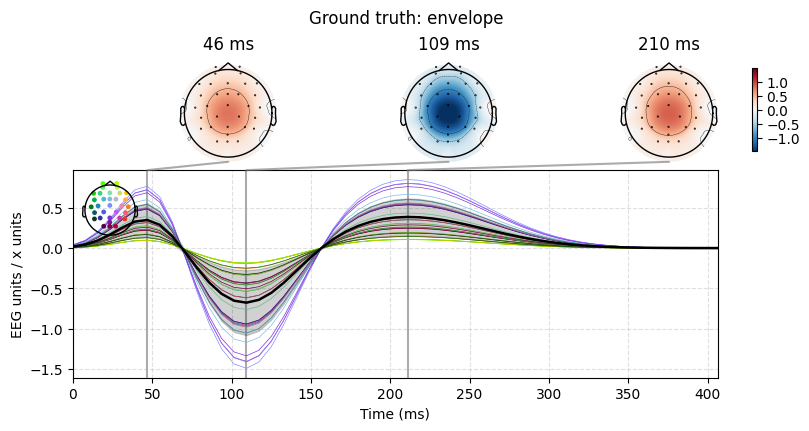

In [5]:
truth.plot_joint("envelope", show=True);

## 2 · Recovering it

`simulate` returned the container with the montage already in `TRFData.info`, as an
`mne.Raw` recording would have brought it. `segments_as_folds=True` makes each recorded
segment its own fold — the natural choice when segments are the unit of the
experiment.

In [6]:
data.create_partitions(segments_as_folds=True)   # lazy: recorded now, built at materialize
print("montage carried:", data.info is not None, " | segments:", len(data.raw_targets))

montage carried: True  | segments: 3


In [7]:
model = TRFModel(TRFDataset=data, features=["envelope", "spectrogram"],
                 default_window=WINDOW, solver="ridge")
best_regularization, (trfs, corr) = model.gridsearchCV(
    regularization_grid=GRID, validation_plot=False, run_fit=True)
print(f"λ = {best_regularization:.3g}   mean held-out r = {float(corr.mean()):.3f}")

α = 0.811   mean held-out r = 0.474


Now the comparison that only simulation allows. The recovered kernel is in
standardized coefficient units and the ground truth in the simulation's own, so they are each normalised
before overlaying — what is being judged is **shape and latency**, not amplitude.

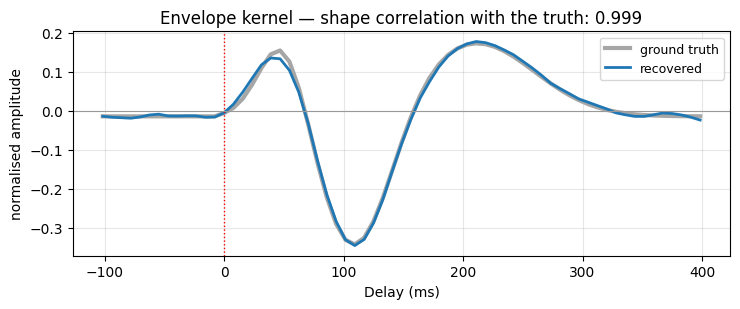

In [8]:
def recovered(m, spec="envelope"):
    """Channel-averaged kernel and its delay axis in ms, via the Evoked bridge."""
    ev = m.to_evoked()[spec]
    return ev.times * 1e3, ev.data.mean(axis=0)


def unit(x):
    """Zero-mean, unit-norm — so shapes can be compared regardless of scale."""
    x = np.asarray(x, dtype=float) - np.mean(x)
    return x / (np.linalg.norm(x) + 1e-12)


# The truth laid on the model's own lags -- the shape of coef_ -- then averaged over
# channels, like the recovered kernel.
t_ms = truth.times("envelope", WINDOW) * 1e3
gt_kernel = truth.kernel("envelope", WINDOW)[:, 0].mean(axis=0)

lags, rec = recovered(model)
fidelity = float(np.dot(unit(rec), unit(gt_kernel)))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(t_ms, unit(gt_kernel), lw=3, color=".65", label="ground truth")
ax.plot(lags, unit(rec), lw=2, color="C0", label="recovered")
ax.axvline(0, color="r", ls=":", lw=1); ax.axhline(0, color=".6", lw=.8)
ax.set(xlabel="Delay (ms)", ylabel="normalised amplitude",
       title=f"Envelope kernel — shape correlation with the truth: {fidelity:.3f}")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout()

That single number — the correlation between the recovered shape and the injected one — is
the currency of the rest of the notebook. On real data it does not exist, which is why
every claim about an estimator being biased has to be argued rather than measured. Here it
can simply be computed.

## 3 · Three cross-validation paradigms, judged against the truth

TRFlearn offers three, and the documentation is candid that two of them are optimistic:

- **`pooled`** — standard k-fold. For each held-out fold a model is fitted on the pooled
  complement, with an inner split to choose λ. Nothing in the reported score was seen while
  fitting.
- **`averaged`** — the Crosse–Lalor leave-one-out scheme: one model per partition, each
  fold predicted by the average of the others' models. Mildly optimistic, because the
  held-out fold is standardised with its own statistics.
- **`train_test`** — a single contiguous split, with λ chosen on the **test** fold. The
  simplest, and the most optimistic: the reported set is the selection set.

On real data you would have to take that ordering on trust. Here both quantities are
available at once — what each paradigm *reports*, and how well it actually recovered the
kernel — so the gap between them can be read off directly.

In [9]:
def fit_paradigm(cv, feats, container, **kw):
    """Fit one paradigm on one container and report (λ, held-out r, fidelity)."""
    m = TRFModel(TRFDataset=container, features=feats,
                 default_window=WINDOW, cv=cv, **kw)
    regularization, (_, score) = m.gridsearchCV(regularization_grid=GRID, validation_plot=False,
                                       run_fit=True)
    lg, rc = recovered(m)
    fid = float(np.dot(unit(rc), unit(gt_kernel)))
    return regularization, float(np.asarray(score.cpu()).mean()), fid, (lg, rc)


def containers(subject):
    """A k-fold container and a single-split one over the same recording."""
    kfold = TRFData(features=subject.raw_features, y=subject.raw_targets,
                    sample_rate=SAMPLE_RATE, info=subject.info)
    kfold.create_partitions(segments_as_folds=True)
    split = TRFData(features=subject.raw_features, y=subject.raw_targets,
                    sample_rate=SAMPLE_RATE, info=subject.info)
    split.create_partitions(train_size=0.8)
    return kfold, split


# noise standard deviation as a multiple of the signal's, and the SNR it means
NOISE_LEVELS = {"noise 1.6x signal": 1.6, "noise 6x signal": 6.0}

results = {}
for label, ratio in NOISE_LEVELS.items():
    subject, _ = make_subject(seed=42, snr_db=-20 * np.log10(ratio))
    kfold, split = containers(subject)

    print()
    print(f"{label} ({-20 * np.log10(ratio):.1f} dB)")
    print(f"  {'paradigm':12s} {'λ':>9s} {'reported r':>12s} {'fidelity':>10s}")
    for cv, cont in [("pooled", kfold), ("averaged", kfold), ("train_test", split)]:
        a, rep, fid, curve = fit_paradigm(cv, ["envelope"], cont)
        results[(label, cv)] = (a, rep, fid, curve)
        print(f"  {cv:12s} {a:>9.3g} {rep:>12.3f} {fid:>10.3f}")


noise 1.6x signal (-4.1 dB)
  paradigm         alpha   reported r   fidelity
  pooled            15.2        0.244      0.983
  averaged         0.811        0.246      0.995


  train_test        65.8        0.272      0.977

noise 6x signal (-15.6 dB)
  paradigm         alpha   reported r   fidelity
  pooled            15.2        0.072      0.981


  averaged          15.2        0.072      0.982
  train_test        65.8        0.081      0.973


**All three recover the kernel, at both noise levels.** The fidelities sit between 0.97 and
0.995 throughout — with three 45-second segments and a single predictor, the choice of
cross-validation scheme simply does not determine whether the TRF comes back. That is worth
knowing before agonising over it.

**Where they differ is in the number each reports about itself.** `train_test` reports the
highest r in *both* conditions while its fidelity is the lowest of the three in both — it is not
recovering more, it is grading itself more generously, because the λ it chose was selected
on the very fold it then reports. The offset is small here, but it is in the direction the
documentation warns about and it survives the change in noise.

The effect is modest because this problem is easy. It grows exactly where you would expect
— less data per subject, more predictors, lower SNR — and the reason to have measured it on
a simulation is so you know which way it leans before you meet a dataset where it matters.

One honest caveat: this is a single simulated subject at two noise levels, so read the
direction, not the decimals.

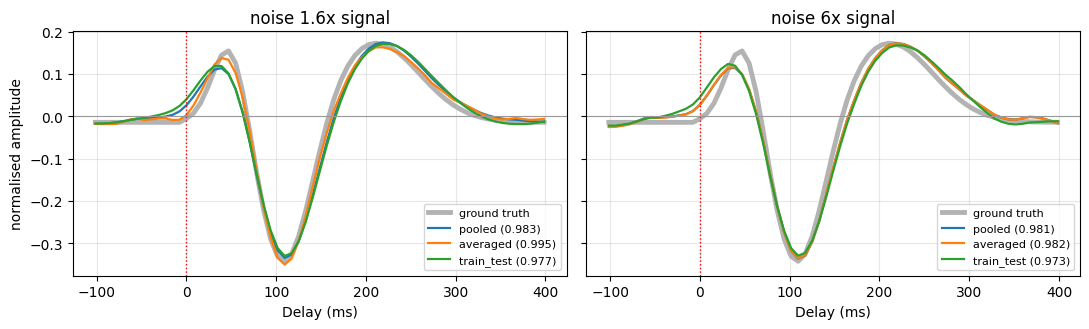

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, label in zip(axes, NOISE_LEVELS):
    ax.plot(t_ms, unit(gt_kernel), lw=3.5, color=".7", label="ground truth", zorder=1)
    for i, cv in enumerate(["pooled", "averaged", "train_test"]):
        _, _, fid, (lg, rc) = results[(label, cv)]
        ax.plot(lg, unit(rc), lw=1.6, color=f"C{i}", label=f"{cv} ({fid:.3f})")
    ax.axvline(0, color="r", ls=":", lw=1); ax.axhline(0, color=".6", lw=.8)
    ax.set(xlabel="Delay (ms)", title=label)
    ax.legend(fontsize=8); ax.grid(alpha=.3)
axes[0].set_ylabel("normalised amplitude")
plt.tight_layout()

## 4 · Per-feature windows, and bases

A model does not have to give every predictor the same delay window. `feature_windows`
overrides the default per feature — useful when one predictor is known to act fast and
another slowly. `feature_bases` works on a different axis: not the lags but the feature's *value*. It
expands each sample of the stimulus through a basis — `spline_basis`, or any
scikit-learn transformer — before lagging, so every basis column gets its own kernel and
the response can depend non-linearly on the stimulus amplitude, loud and soft sounds
evoking differently shaped responses. [Features & windows](../../concepts/features/#basis-expansions-feature_bases)
covers it; this section only narrows a window.

Both are declared on the model, so the same container serves either.

In [11]:
narrow = TRFModel(TRFDataset=data, features=["envelope"], default_window=WINDOW,
                  feature_windows={"envelope": (-0.05, 0.25)},
                  feature_preprocess=None, target_preprocess=None)
narrow.fit(regularization=1e3)

lg_n, rc_n = recovered(narrow)
print(f"default window {WINDOW} s -> {len(recovered(model)[0])} lags")
print(f"narrowed to (-0.05, 0.25) s -> {len(lg_n)} lags, "
      f"coef shape {tuple(narrow.coef_['envelope'].shape)}")
print("\nStandardisation is off here (feature_preprocess=None), so the coefficients are")
print("in raw units rather than sigma_EEG/sigma_x -- which is why λ is fixed by hand:")
print("a grid tuned for standardised data would not transfer.")

default window (-0.1, 0.4) s -> 65 lags
narrowed to (-0.05, 0.25) s -> 39 lags, coef shape (32, 1, 39)

Standardisation is off here (feature_preprocess=None), so the coefficients are
in raw units rather than sigma_EEG/sigma_x -- which is why alpha is fixed by hand:
a grid tuned for standardised data would not transfer.


## 5 · Features with more than one column

`envelope` is a scalar predictor: one column, one kernel. `spectrogram` has **five** bands,
so its kernel is `(channels, 5, delays)` and the plots change shape accordingly —
`plot_average` becomes a butterfly *plus* a sub-feature × time heatmap, and `sub_labels`
names the rows.

This is the case the real-data example never reaches, because both of its predictors are
scalar.

In [12]:
print("envelope   coef:", tuple(model.coef_["envelope"].shape), " (channels, d, delays)")
print("spectrogram coef:", tuple(model.coef_["spectrogram"].shape))

envelope   coef: (32, 1, 65)  (channels, d, delays)
spectrogram coef: (32, 5, 65)


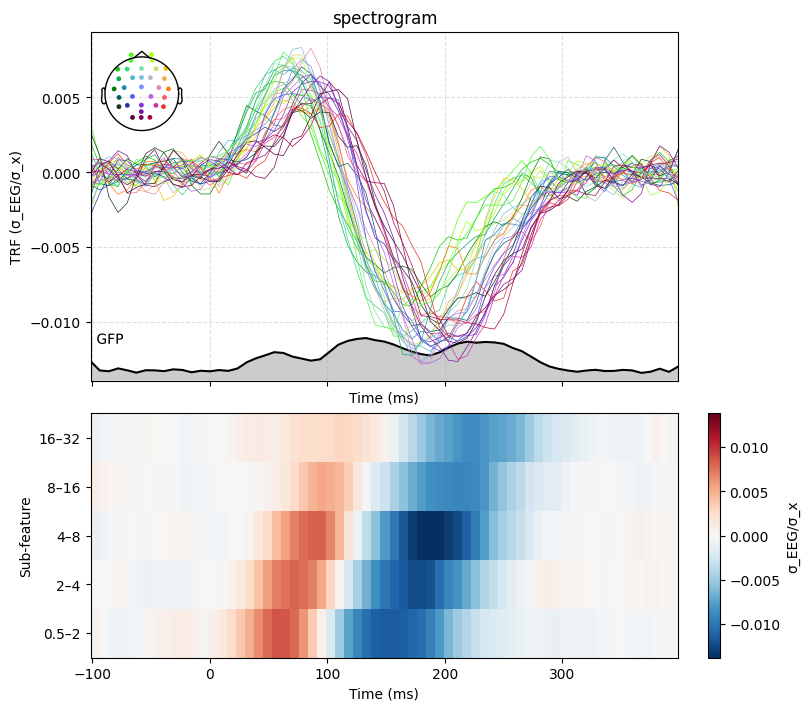

In [13]:
model.plot_average("spectrogram",
                   sub_labels=["0.5–2", "2–4", "4–8", "8–16", "16–32"], show=True);

`subfeature=` picks one column for the `Evoked`-based plots, since an `mne.Evoked` is
strictly channels × time and cannot hold the extra axis.

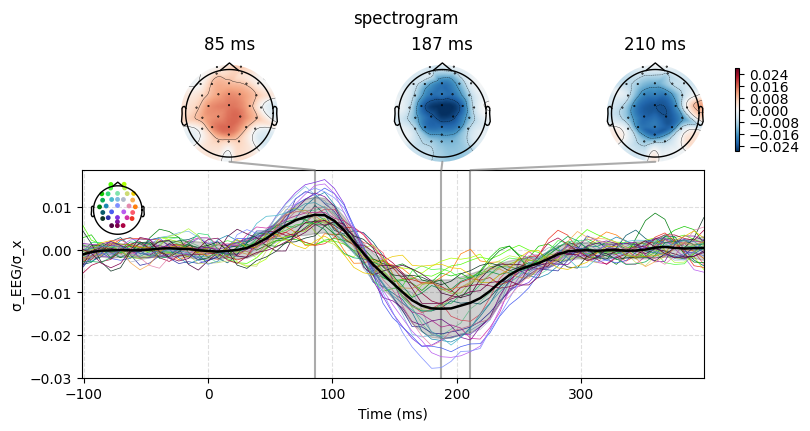

In [14]:
model.plot_joint("spectrogram", subfeature=2, x_units="ms", show=True);

## 6 · Without a montage

Everything so far rode on the sensor positions `simulate` attached. Targets can equally be
plain arrays — but then `TRFData.info` is `None`, and what that costs depends on the
figure. The ones that draw one trace per channel (`plot`, `plot_image`, `plot_psd`,
`plot_average`) need channels, not where they sit, so they still work and name them
`Target 0`, `Target 1`, and so on. The ones that draw a head (`plot_joint`,
`plot_features`, `plot_metric_topomap`) **raise**, because there is nowhere to draw one
from, and the error says what is missing.

The failure is loud, which is the good case. The quiet one is
[`TRFGroup.tfce`](../../examples/02_natural_speech_trf/), which without a montage falls
back to treating every channel as independent and returns a number that looks fine.

info: None


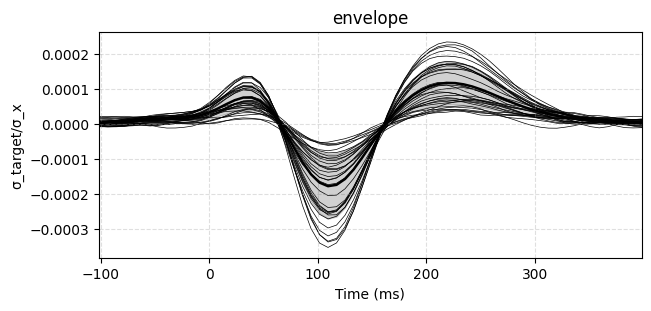

plot_joint without a montage -> plot_joint draws topomaps, which need sensor positions, and there is no channel info. Give the data a montage: TRFData.set_montage, or an mne.Raw that carries one. plot, plot_image, plot_psd and plot_average work without them.


In [15]:
arr_data = TRFData(features={"envelope": data.raw_features["envelope"]},
                   y=data.raw_targets, sample_rate=SAMPLE_RATE)
arr_data.create_partitions(n_folds=4)

arr_model = TRFModel(TRFDataset=arr_data, features=["envelope"], default_window=WINDOW)
arr_model.fit(regularization=1e3)

print("info:", arr_data.info)
arr_model.plot("envelope", show=True)   # one trace per channel: no positions needed

try:
    arr_model.plot_joint("envelope")
except RuntimeError as e:
    print("plot_joint without a montage ->", e)

`set_montage` brings the head figures back when the electrode names are known: build the
`TRFData` with `target_names=[...]`, then call `set_montage("standard_1005")`.

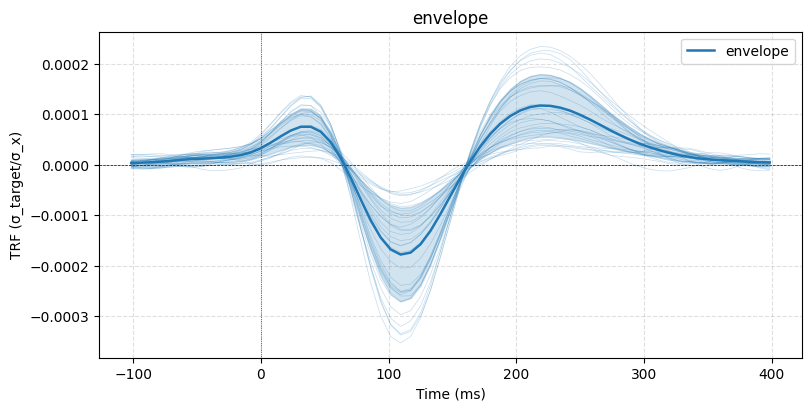

In [16]:
arr_model.plot_average("envelope", x_units="ms", show=True);

---

## Summary

```
envelope / spectrogram + spatiotemporal_kernel(waveform, topography)
   -> simulate(...) -> (TRFData with the montage, GroundTruth)
   -> create_partitions(segments_as_folds=True)
   -> TRFModel(cv="pooled" | "averaged" | "train_test") -> gridsearchCV
   -> compare the recovered kernel against the kernel we injected
```

**What this notebook established.** That the fit recovers the injected kernel; that the
three CV paradigms differ in how generously they score themselves, measurably and in the
direction the documentation warns about; that windows and bases are per-feature model
decisions over a shared container; that multi-column features keep their sub-feature axis
throughout; and that losing the montage costs the head figures loudly and the group
statistics quietly.

**Next:** the same library on a real 17-subject EEG cohort, with group statistics and TFCE
— [`examples/02_natural_speech_trf.ipynb`](../../examples/02_natural_speech_trf/).